In [1]:
import numpy as np
import sys
import numpy as np
from sklearn.decomposition import PCA

In [16]:
def generate_smiley(nsamples=600):
    np.random.seed(42)
    # Distribute points evenly
    face_points = nsamples // 2
    eye_points = nsamples // 10
    smile_points = nsamples - (face_points + 2 * eye_points)

    # Generate circle for face outline
    theta = np.linspace(0, 2 * np.pi, face_points)
    x_face = np.cos(theta)
    y_face = np.sin(theta)
    
    # Generate eyes
    eye_theta = np.linspace(0, 2 * np.pi, eye_points)
    x_eye1 = -0.5 + 0.1 * np.cos(eye_theta)
    y_eye1 = 0.5 + 0.1 * np.sin(eye_theta)
    x_eye2 = 0.5 + 0.1 * np.cos(eye_theta)
    y_eye2 = 0.5 + 0.1 * np.sin(eye_theta)
    
    # Generate smile
    smile_theta = np.linspace(0, np.pi, smile_points)
    x_smile = 0.6 * np.cos(smile_theta)
    y_smile = -0.6 * np.sin(smile_theta) - 0.2
    
    # Combine all parts
    x = np.concatenate([x_face, x_eye1, x_eye2, x_smile])
    y = np.concatenate([y_face, y_eye1, y_eye2, y_smile])
    
    return np.stack((x, y), axis=1)

## Create some synthetic data

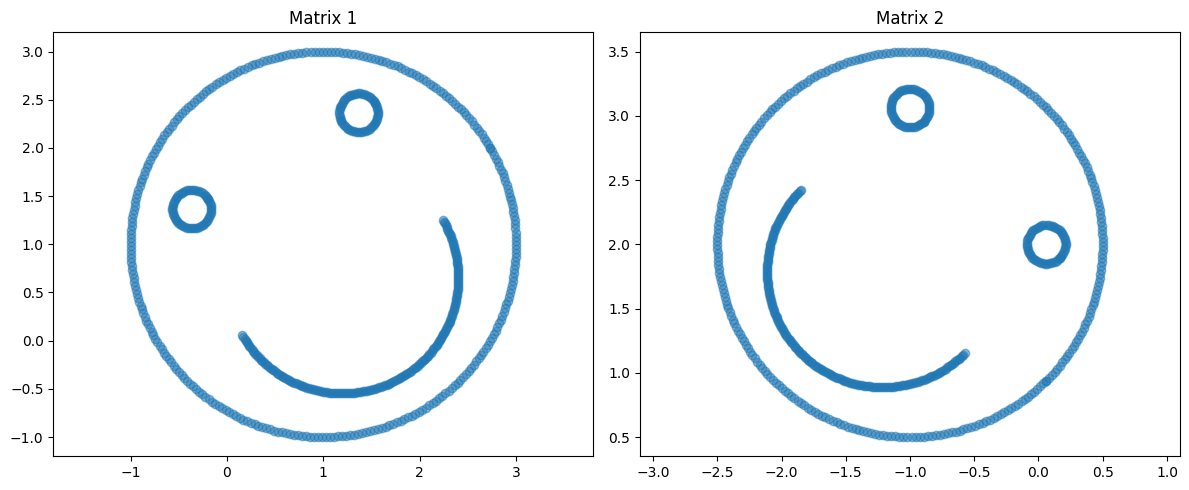

Shape of matrix1: (600, 100)
Shape of matrix2: (600, 100)


In [17]:
# Generate synthetic smiley face data
features = 100
nsamples = 600

# Generate smiley face points
smiley = generate_smiley(nsamples)

# Function to create a transformation matrix that preserves structure
def create_transformation(scale=1, rotation=0, translation=(0, 0)):
    cos_theta = np.cos(rotation)
    sin_theta = np.sin(rotation)
    tx, ty = translation
    
    transform = np.array([
        [scale * cos_theta, -scale * sin_theta, tx],
        [scale * sin_theta, scale * cos_theta, ty],
        [0, 0, 1]
    ])
    
    return transform

# Create two slightly different transformations
transform1 = create_transformation(scale=2, rotation=np.pi/6, translation=(1, 1))
transform2 = create_transformation(scale=1.5, rotation=-np.pi/4, translation=(-1, 2))

# Apply transformations to smiley faces
smiley_homogeneous = np.column_stack([smiley, np.ones(nsamples)])
transformed_smiley1 = (smiley_homogeneous @ transform1.T)[:, :2]
transformed_smiley2 = (smiley_homogeneous @ transform2.T)[:, :2]

# Add some noise to create additional features
noise_scale = 0.05
additional_features1 = np.random.randn(nsamples, features - 2) * noise_scale
additional_features2 = np.random.randn(nsamples, features - 2) * noise_scale

# Combine transformed smileys with additional features
matrix1 = np.hstack([transformed_smiley1, additional_features1])
matrix2 = np.hstack([transformed_smiley2, additional_features2])

# Plot the results
plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.scatter(matrix1[:, 0], matrix1[:, 1], alpha=0.5)
plt.title("Matrix 1")
plt.axis('equal')

plt.subplot(122)
plt.scatter(matrix2[:, 0], matrix2[:, 1], alpha=0.5)
plt.title("Matrix 2")
plt.axis('equal')

plt.tight_layout()
plt.show()

print("Shape of matrix1:", matrix1.shape)
print("Shape of matrix2:", matrix2.shape)

In [ ]:
features = 100
nsamples = 500
nlatent = 10

#Create a time vector
t = np.linspace(0, 2 * np.pi, nsamples)

# Generate latent features with sinusoidal patterns and noise
latent_features = np.array([np.sin(t * (i+1)) + 0.1 * np.random.randn(nsamples) for i in range(nlatent)]).T

# Generate transformation matrices
transformation1 = np.random.rand(nlatent, features)
transformation2 = transformation1 + np.random.rand(nlatent, features) * 0.1  # Slightly shifted

# Generate matrices by applying transformations
matrix1 = latent_features @ transformation1
matrix2 = latent_features @ transformation2

In [18]:
def is_invertible(A):
    """Check if a matrix is invertible.
    
    A high condition number indicates that the matrix is nearly singular (i.e., close to being non-invertible), 
    while a low condition number indicates that the matrix is well-conditioned (i.e., far from being singular).
    
    sys.float_info.epsilon is the smallest representable positive number such that 1.0 + epsilon != 1.0.
    
    If the condition number is less than 1/epsilon, the matrix is considered to be invertible.
    """
    if np.linalg.cond(A) < 1/sys.float_info.epsilon:
        return True
    else:
        return False

## Check if matrix is invertible and thus whether factorisation will be unique

In [19]:
# Check if matrices are invertible
if is_invertible(matrix1) and is_invertible(matrix2):
    print("Factorisation with QR is unique as both matrices are invertible.")
else:
    print("Factorisation with QR is not unique as at least one of the matrices is non-invertible.")

Factorisation with QR is unique as both matrices are invertible.


# Perform PCA

In [20]:
ncomp = 10
pca = PCA(n_components=ncomp)
A1 = pca.fit_transform(matrix1) # (nsamples, ncomp)
A2 = pca.fit_transform(matrix2) # (nsamples, ncomp)
print(A1.shape)
assert A1.shape == (nsamples, ncomp), "The shape of A1 is incorrect."
assert A2.shape == (nsamples, ncomp), "The shape of A2 is incorrect."


(600, 10)


## Align shapes to match Gallego notation

In [21]:
A1 = A1.T # (ncomp, nsamples)
A2 = A2.T # (ncomp, nsamples)
assert A1.shape == (ncomp, nsamples), "The shape of A1 is incorrect."
assert A2.shape == (ncomp, nsamples), "The shape of A2 is incorrect."

## Perform QR Decomposition

In [22]:
# Q is an orthogonal matrix, and R is an upper triangular matrix
# In Q, each row represents a principal component, and each column represents an ONB across the principal components
# This ensures the columns of Q are orthogonal to each other
# R transforms the columns from the ONB to the original space of A
Q1, R1 = np.linalg.qr(A1.T)
print(f"The shape of Q1 is {Q1.shape} and the shape of R1 is {R1.shape}.")
import matplotlib.pyplot as plt
#plt.imshow(Q1)
# invert y axis
#plt.gca().invert_yaxis()
Q2, R2 = np.linalg.qr(A2.T)
print(Q1.shape)
#assert Q1.shape == (ncomp, ncomp), "The shape of Q1 is incorrect."
#assert Q2.shape == (ncomp, ncomp), "The shape of Q2 is incorrect."

# The shape of the Rs should be square else we can't invert them in the following step
assert R1.shape == (ncomp, ncomp), "The shape of R1 is incorrect."
assert R2.shape == (ncomp, ncomp), "The shape of R2 is incorrect."


The shape of Q1 is (600, 10) and the shape of R1 is (10, 10).
(600, 10)


## Perform Inner product and SVD

In [23]:
# Compute how similar the linear latent spaces are between matrices A1 and A2
inner_product = Q1.T@Q2
assert inner_product.shape == (ncomp, ncomp), "The shape of the inner product is incorrect it must be square."
U, S, V = np.linalg.svd(inner_product) # Take the ONB of the PCS of A1 and compute the dot product with the ONB of the PCS of A2
# Paper says this produces USV^T so we need to take the transpose of V^T to get V
V = V.T # (ncomp, ncomp) so could be wrong...

## Project the latent spaces to new manifold directions

In [24]:
# print some shapes
print(f"U shape: {U.shape}")
print(f"S shape: {S.shape}")
print(f"V shape: {V.shape}")

# Learn the transformation matrices M_a and M_b which map the linear latent spaces of A1 and A2 to each other
M_a = np.linalg.inv(R1)@U
M_b = np.linalg.inv(R2)@V

# Now map the linear latent spaces of A1 and A2 to a shared axis
A1_mapped = A1.T@M_a
A2_mapped = A2.T@M_b

# Check the shapes
print(f"A1_mapped shape: {A1_mapped.shape}")
print(f"A2_mapped shape: {A2_mapped.shape}")
print(f"A1 shape: {A1.shape}")
print(f"A2 shape: {A2.shape}")

U shape: (10, 10)
S shape: (10,)
V shape: (10, 10)
A1_mapped shape: (600, 10)
A2_mapped shape: (600, 10)
A1 shape: (10, 600)
A2 shape: (10, 600)


## Plot your amazing results...

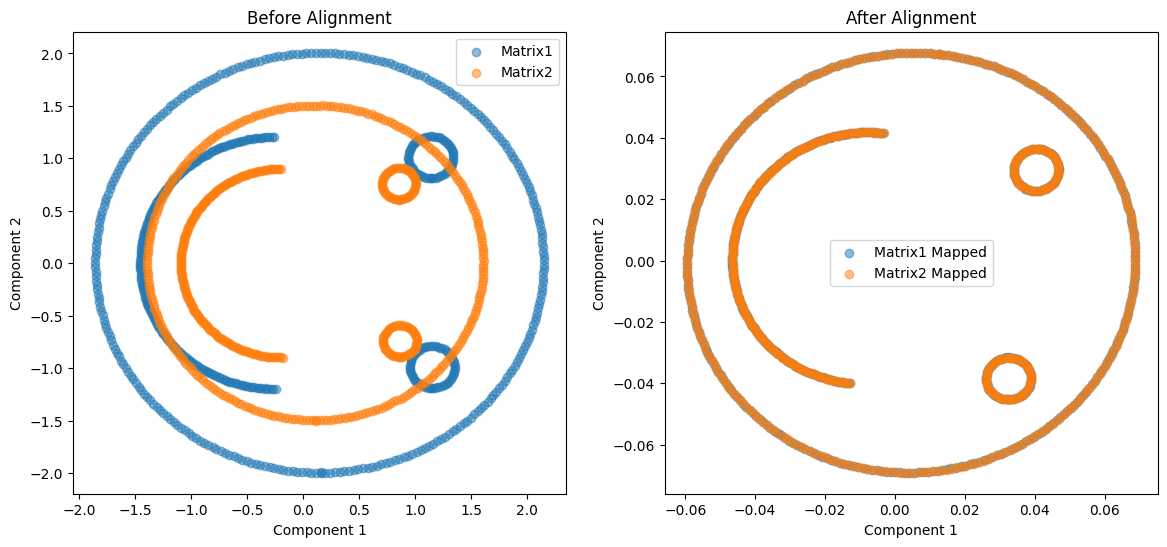

In [25]:
# Plotting before alignment
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(A1[0, :], A1[1, :], alpha=0.5, label='Matrix1') # Plot the first two components of A1 and all samples
plt.scatter(A2[0, :], A2[1, :], alpha=0.5, label='Matrix2') # Plot the first two components of A2 and all samples
plt.title('Before Alignment')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend()

# Plotting after alignment
plt.subplot(1, 2, 2)
plt.scatter(A1_mapped[:, 0], A1_mapped[:, 1], alpha=0.5, label='Matrix1 Mapped')
plt.scatter(A2_mapped[:, 0], A2_mapped[:, 1], alpha=0.5, label='Matrix2 Mapped')
plt.title('After Alignment')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend()

plt.show()